# **04 빌트인 미들웨어 활용하기**

### 학습 내용
1. 미들웨어 개념 이해
2. LangChain 빌트인 미들웨어 사용하기

## 1. 환경 설정

- OpenAI API Key 발급: https://platform.openai.com/api-keys

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("OPENAI API Key가 설정되었습니다.")

OPENAI API Key가 설정되었습니다.


## 2. 미들웨어란?

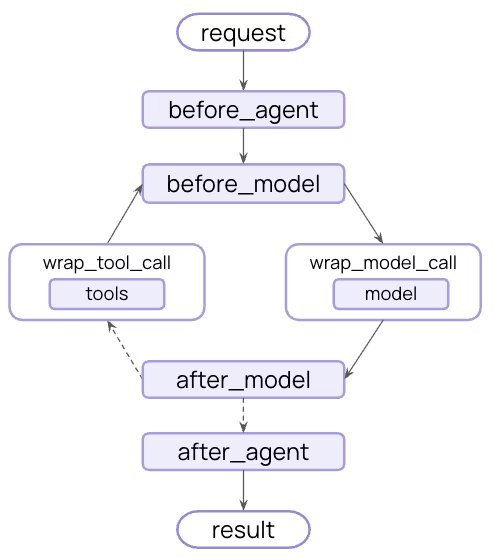

**미들웨어(Middleware)** 는 에이전트 실행의 각 단계에서 동작을 제어하고 커스터마이징할 수 있는 메커니즘입니다.

### 미들웨어의 용도

- **추적 및 로깅**: 에이전트 동작 모니터링, 분석, 디버깅
- **변환**: 프롬프트, 도구 선택, 출력 형식 변경
- **제어 흐름**: 재시도, 폴백, 조기 종료 로직
- **제한 및 보호**: 속도 제한, 가드레일, PII 탐지

### 에이전트 실행 흐름

```
before_agent
    ↓
    before_model → MODEL CALL → after_model
    ↓
    wrap_tool_call → TOOL EXECUTION
    ↓
after_agent
```

미들웨어는 이러한 각 단계에서 개입하여 동작을 제어할 수 있습니다.

## 3. 빌트인 미들웨어 1: TodoListMiddleware - 할일 계획 수립

https://github.com/langchain-ai/langchain/blob/master/libs/langchain_v1/langchain/agents/middleware/todo.py

In [2]:
from langchain.agents import create_agent
from langchain.agents.middleware import TodoListMiddleware
from langchain.tools import tool


# 여러 가짜 도구들 정의 (코드 리팩토링 시나리오)
@tool
def list_files(directory: str = ".") -> str:
    """프로젝트의 파일 목록을 가져옵니다."""
    return "main.py, utils.py, models.py, tests.py"

@tool
def read_file(filename: str) -> str:
    """파일의 내용을 읽습니다."""
    return f"{filename}의 내용 (1000줄)"

@tool
def analyze_code(filename: str) -> str:
    """코드의 품질을 분석합니다."""
    return f"{filename}: 복잡도 높음, 중복 코드 발견, 리팩토링 필요"

@tool
def refactor_code(filename: str, method: str) -> str:
    """코드를 리팩토링합니다."""
    return f"{filename}을(를) {method} 방식으로 리팩토링 완료"

@tool
def run_tests(test_file: str) -> str:
    """테스트를 실행합니다."""
    return f"{test_file}: 모든 테스트 통과 ✓"

@tool
def create_backup(files: str) -> str:
    """파일 백업을 생성합니다."""
    return f"{files} 백업 완료"

@tool
def commit_changes(message: str) -> str:
    """변경사항을 커밋합니다."""
    return f"커밋 완료: {message}"

@tool
def generate_documentation(filename: str) -> str:
    """코드 문서를 생성합니다."""
    return f"{filename}의 문서 생성 완료"

# TodoListMiddleware를 사용하는 에이전트
agent = create_agent(
    model="gpt-4o-mini",
    tools=[
        list_files,
        read_file,
        analyze_code,
        refactor_code,
        run_tests,
        create_backup,
        commit_changes,
        generate_documentation,
    ],
    middleware=[TodoListMiddleware()], # write_todos / @wrap_model_call / @after_model(write_todos 도구가 여러번 호출되었으면 tools 노드로 보내지지 않도록 막음)
)

In [3]:
# Stream 모드로 에이전트의 계획 수립 과정 확인
user_message = [{"role": "user", "content": "레거시 코드베이스를 완전히 리팩토링하려고 합니다. 체계적으로 진행해주세요."}]

for i, chunk in enumerate(agent.stream({"messages": user_message}, stream_mode="updates"), 1):
    for node, value in chunk.items():
        print(f"\n━━━ 단계 {i}: {node} ━━━")

        # value가 None이 아닌 경우만 처리
        if value is not None and "messages" in value:
            for msg in value["messages"]:
                if hasattr(msg, 'content') and msg.content:
                    # AI 메시지의 경우
                    print(f"💬 AI: {msg.content}" if len(msg.content) > 200 else f"💬 AI: {msg.content}")

                # 도구 호출이 있는 경우
                if hasattr(msg, 'tool_calls') and msg.tool_calls:
                    for tool_call in msg.tool_calls:
                        print(f"🔧 도구 호출: {tool_call.get('name', 'unknown')}")
                        if 'args' in tool_call:
                            print(f"   인자: {tool_call['args']}")

                # 도구 응답인 경우
                if hasattr(msg, 'name') and msg.name:
                    print(f"✅ 도구 결과 ({msg.name}): {msg.content}" if len(msg.content) > 100 else f"✅ 도구 결과 ({msg.name}): {msg.content}")
                    print()


━━━ 단계 1: model ━━━
🔧 도구 호출: write_todos
   인자: {'todos': [{'content': '리팩토링할 코드베이스의 파일 목록 가져오기', 'status': 'in_progress'}, {'content': '각 파일의 내용을 검토하여 리팩토링 계획 수립하기', 'status': 'pending'}, {'content': '각 파일의 품질 분석하기', 'status': 'pending'}, {'content': '리팩토링 수행하기', 'status': 'pending'}, {'content': '변경 사항 커밋하기', 'status': 'pending'}, {'content': '문서화 및 테스트 수행하기', 'status': 'pending'}]}

━━━ 단계 2: TodoListMiddleware.after_model ━━━

━━━ 단계 3: tools ━━━
💬 AI: Updated todo list to [{'content': '리팩토링할 코드베이스의 파일 목록 가져오기', 'status': 'in_progress'}, {'content': '각 파일의 내용을 검토하여 리팩토링 계획 수립하기', 'status': 'pending'}, {'content': '각 파일의 품질 분석하기', 'status': 'pending'}, {'content': '리팩토링 수행하기', 'status': 'pending'}, {'content': '변경 사항 커밋하기', 'status': 'pending'}, {'content': '문서화 및 테스트 수행하기', 'status': 'pending'}]
✅ 도구 결과 (write_todos): Updated todo list to [{'content': '리팩토링할 코드베이스의 파일 목록 가져오기', 'status': 'in_progress'}, {'content': '각 파일의 내용을 검토하여 리팩토링 계획 수립하기', 'status': 'pending'}, {'content': '

## 4. 빌트인 미들웨어 2: SummarizationMiddleware - 대화 히스토리 요약

긴 대화 히스토리를 자동으로 요약하여 컨텍스트 길이를 관리합니다.

- 토큰 또는 메시지 수 기반 요약 트리거
- 최근 메시지 보존
- 오래된 컨텍스트 압축
- 비용 절감

https://github.com/langchain-ai/langchain/blob/master/libs/langchain_v1/langchain/agents/middleware/summarization.py

In [4]:
from langchain.tools import tool

@tool
def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's sunny in {city}!"

@tool
def calculator(expression: str) -> str:
    """Evaluate a mathematical expression."""
    try:
        result = eval(expression, {"__builtins__": {}}, {})
        return f"Result: {result}"
    except Exception as e:
        return f"Error: {str(e)}"

In [5]:
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver

# 대화 요약 미들웨어
summary_agent = create_agent(
    model="gpt-4o-mini",
    tools=[get_weather, calculator],
    checkpointer=InMemorySaver(),  # 상태 저장 필요
    middleware=[
        SummarizationMiddleware( # before_model
            model="gpt-4o-mini",
            # 6개 메시지에 도달하면 요약 시작 (테스트용으로 낮게 설정)
            trigger=("messages", 6),
            # 최근 3개 메시지는 보존
            keep=("messages", 3),
        )
    ],
)

In [6]:
# 요약 동작 확인을 위한 긴 대화
config = {"configurable": {"thread_id": "thread_1"}}

# 여러 메시지 전송
messages = [
    "안녕하세요, 서울의 날씨가 어떤가요?",
    "오늘은 외출을 해야겠네요.",
    "123 * 123 을 계산해주세요.",
    "도쿄의 날씨에 대해 알려주세요.",
    "100 - 50 을 계산해주세요.",
    "15 * 3 은 얼마인가요?",
    "파리의 날씨는 어떤가요?",
    "200 - 75 를 계산해주세요.",
]

for i, msg in enumerate(messages, 1):
    print(f"\n{'='*60}")
    print(f"📨 메시지 {i}/{len(messages)}: {msg}")
    print(f"{'='*60}")

    response = summary_agent.invoke(
        {"messages": [{"role": "user", "content": msg}]},
        config=config
    )

    total_msgs = len(response['messages'])
    user_msgs = sum(1 for m in response['messages'] if hasattr(m, 'type') and m.type == 'human')
    ai_msgs = sum(1 for m in response['messages'] if hasattr(m, 'type') and m.type == 'ai')

    print(f"응답: {response['messages'][-1].content}")
    print(f"메시지 현황: 총 {total_msgs}개 (사용자: {user_msgs}, AI: {ai_msgs})")
    for msg in response['messages']:
        print(f"- {msg.content}")


📨 메시지 1/8: 안녕하세요, 서울의 날씨가 어떤가요?
응답: 안녕하세요! 서울의 날씨는 맑습니다.
메시지 현황: 총 4개 (사용자: 1, AI: 2)
- 안녕하세요, 서울의 날씨가 어떤가요?
- 
- It's sunny in 서울!
- 안녕하세요! 서울의 날씨는 맑습니다.

📨 메시지 2/8: 오늘은 외출을 해야겠네요.
응답: 좋은 생각이에요! 맑은 날씨에 외출하면 기분이 좋을 겁니다. 무엇을 할 계획이신가요?
메시지 현황: 총 6개 (사용자: 2, AI: 3)
- 안녕하세요, 서울의 날씨가 어떤가요?
- 
- It's sunny in 서울!
- 안녕하세요! 서울의 날씨는 맑습니다.
- 오늘은 외출을 해야겠네요.
- 좋은 생각이에요! 맑은 날씨에 외출하면 기분이 좋을 겁니다. 무엇을 할 계획이신가요?

📨 메시지 3/8: 123 * 123 을 계산해주세요.
응답: 123 * 123의 결과는 15129입니다.
메시지 현황: 총 5개 (사용자: 2, AI: 2)
- Here is a summary of the conversation to date:

## SESSION INTENT
The user's primary goal is to inquire about the current weather in Seoul.

## SUMMARY
The user asked about the weather in Seoul, to which the AI confirmed it is sunny. The user expressed a plan to go out, and the AI encouraged the idea, suggesting the pleasant weather would be good for an outing.

## ARTIFACTS
None

## NEXT STEPS
None
- 123 * 123 을 계산해주세요.
- 
- Result: 15129
- 123 * 123의 결과는 15129입니다.

📨 메시지 4/8: 도쿄의 날씨에 대해 알려주세요.
응답: 도쿄의

## 5. 빌트인 미들웨어 3: ToolRetryMiddleware - 도구 재시도

https://github.com/langchain-ai/langchain/blob/master/libs/langchain_v1/langchain/agents/middleware/tool_retry.py

**ToolRetryMiddleware 파라미터 정리**

1. `max_retries`
- 재시도 횟수 (초기 1회 + retries)
- 총 시도 횟수 = `max_retries + 1`

2. `tools`
- retry 적용할 tool 지정
- `None`이면 모든 tool에 적용

3. `retry_on`
- 어떤 예외에서 retry할지 정의
- 예외 타입 tuple 또는 함수로 설정 가능

4. `on_failure`
- retries 모두 실패 시 동작
- `"continue"`: ToolMessage 반환 (기본)
- `"error"`: 예외 발생 (중단)
- `callable`: 커스텀 메시지 반환

5. `backoff_factor`
- 재시도 간 대기 시간 증가 비율 (exponential backoff)
- `delay = initial_delay * (backoff_factor ** attempt)`

6. `initial_delay`
- 첫 retry 전 대기 시간 (초)

7. `max_delay`
- 최대 대기 시간 제한 (초)

8. `jitter`
- 대기 시간에 ±랜덤 추가 (기본 ±25%)
- 동시 재요청 폭발(Thundering Herd) 방지

In [7]:
from langchain.agents.middleware import ToolRetryMiddleware
import random

@tool
def flaky_api(query: str) -> str:
    """재시도 로직을 시연하기 위해 무작위로 실패하는 API"""
    import time
    print(f"⏱️ [{time.strftime('%H:%M:%S')}] flaky_api 호출 시도...")

    if random.random() < 0.7:  # 70% 실패 확률
        print(f"❌ [{time.strftime('%H:%M:%S')}] 실패: Network error")
        raise Exception("Network error")

    print(f"✅ [{time.strftime('%H:%M:%S')}] 성공!")
    return f"성공: {query}"

# 도구 재시도 미들웨어
tool_retry_agent = create_agent(
    model="gpt-4o-mini",
    tools=[flaky_api],
    middleware=[
        ToolRetryMiddleware(
            max_retries=3,
            backoff_factor=2.0,
            initial_delay=0.5,
        )
    ],
)

In [9]:
user_message = [{"role": "user", "content": "Call the flaky API with 'test query'"}]

for i, chunk in enumerate(tool_retry_agent.stream({"messages": user_message}, stream_mode="updates"), 1):
    for node, value in chunk.items():
        print(node)
        print(value)

model
{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 64, 'total_tokens': 80, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b8fcb14f26', 'id': 'chatcmpl-DWbcoKvJ4nYPH1OW9l0eW0LJyHeTe', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019da965-87f9-7b50-b7b8-94a9fb817a21-0', tool_calls=[{'name': 'flaky_api', 'args': {'query': 'test query'}, 'id': 'call_NCOjkPFJkkr1TggT0HqwaAk2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 64, 'output_tokens': 16, 'total_tokens': 80, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasonin

- 미들웨어 없이 그냥 시도했을 때

In [10]:
tool_retry_agent = create_agent(
    model="gpt-4o-mini",
    tools=[flaky_api])

In [12]:
user_message = [{"role": "user", "content": "Call the flaky API with 'test query'"}]

for i, chunk in enumerate(tool_retry_agent.stream({"messages": user_message}, stream_mode="updates"), 1):
    for node, value in chunk.items():
        print(node)
        print(value)

model
{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 64, 'total_tokens': 80, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_4181e24c46', 'id': 'chatcmpl-DWbdSAmdd0WnHEYycBdtlu9Ck66I7', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019da966-2588-7092-96c5-2064be6b45c0-0', tool_calls=[{'name': 'flaky_api', 'args': {'query': 'test query'}, 'id': 'call_L60BZyzzoEKk52iQmdk26Xaf', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 64, 'output_tokens': 16, 'total_tokens': 80, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasonin

Exception: Network error

## 6. 빌트인 미들웨어 4: PIIMiddleware - 개인정보 보호

개인식별정보(PII)를 자동으로 탐지하고 처리합니다.

- 이메일, 전화번호, IP 주소, MAC 주소, URL, 신용카드 탐지
- PII 차단, 제거, 마스킹, 해싱 전략
- 입력, 출력, 도구 결과에 선택적 적용

### 빌트인 PII 타입

- `email`: 이메일 주소
- `credit_card`: 신용카드 번호 (Luhn 알고리즘 검증)
- `ip`: IP 주소
- `mac_address`: MAC 주소
- `url`: URL (http/https 및 일반 URL)

https://github.com/langchain-ai/langchain/blob/master/libs/langchain_v1/langchain/agents/middleware/pii.py

In [13]:
from langchain.agents.middleware import PIIMiddleware

# PII 보호 미들웨어 (각 타입마다 별도 인스턴스)
pii_agent = create_agent(
    model="gpt-4o-mini",
    tools=[get_weather, calculator],
    middleware=[
        # 이메일 제거
        PIIMiddleware(
            "email",
            strategy="redact",
            apply_to_input=True,
        ),
        # 신용카드 부분 마스킹
        PIIMiddleware(
            "credit_card",
            strategy="hash",
            apply_to_input=True,
        ),
        # IP 주소 해싱
        PIIMiddleware(
            "ip",
            strategy="hash",
            apply_to_input=True,
        ),
    ],
)

In [14]:
user_message = [{"role": "user", "content": "내 이메일은 john.doe@example.com, 카드번호는 4242 4242 4242 4242, IP는 192.168.1.1. 읽을 수 있어?"}]

for i, chunk in enumerate(pii_agent.stream({"messages": user_message}, stream_mode="updates"), 1):
    for node, value in chunk.items():
        print("---", node, "---")
        print(value)

--- PIIMiddleware[email].before_model ---
{'messages': [HumanMessage(content='내 이메일은 [REDACTED_EMAIL], 카드번호는 4242 4242 4242 4242, IP는 192.168.1.1. 읽을 수 있어?', additional_kwargs={}, response_metadata={}, id='95b166f7-3a3c-483e-8e7c-2a694b0d93ec')]}
--- PIIMiddleware[credit_card].before_model ---
{'messages': [HumanMessage(content='내 이메일은 [REDACTED_EMAIL], 카드번호는 <credit_card_hash:9219e0af>, IP는 192.168.1.1. 읽을 수 있어?', additional_kwargs={}, response_metadata={}, id='95b166f7-3a3c-483e-8e7c-2a694b0d93ec')]}
--- PIIMiddleware[ip].before_model ---
{'messages': [HumanMessage(content='내 이메일은 [REDACTED_EMAIL], 카드번호는 <credit_card_hash:9219e0af>, IP는 <ip_hash:c5eb5a4c>. 읽을 수 있어?', additional_kwargs={}, response_metadata={}, id='95b166f7-3a3c-483e-8e7c-2a694b0d93ec')]}
--- model ---
{'messages': [AIMessage(content='죄송하지만, 사용자 개인 정보나 민감한 정보를 처리하거나 읽을 수 없습니다. 다른 질문이나 도움이 필요한 사항이 있으시면 말씀해 주세요!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_to

### 📖 과제 1: 빌트인 미들웨어 사용하기

아래 링크를 참고해서 Langchain 빌트인 미들웨어를 사용해보세요:

https://docs.langchain.com/oss/python/langchain/middleware/built-in

In [ ]:
# CODE HERE

---
### 참고 자료

- [Middleware Overview](https://docs.langchain.com/oss/python/langchain/middleware/overview)
- [Built-in Middleware](https://docs.langchain.com/oss/python/langchain/middleware/built-in)
- [Middleware API Reference](https://reference.langchain.com/python/langchain/middleware/)